In [21]:
# Reload the pattern_logic_lib module to pick up debug changes
import importlib
from meteor import pattern_logic_lib
importlib.reload(pattern_logic_lib)
print("✅ Reloaded pattern_logic_lib with debug statements")

✅ Reloaded pattern_logic_lib with debug statements


## 1. Setup and Imports

In [22]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import os
from matplotlib.gridspec import GridSpec
import warnings
import logging

# Suppress warnings
warnings.filterwarnings('ignore')

# Suppress ciceroscm logging warnings
logging.getLogger('ciceroscm').setLevel(logging.ERROR)

# METEOR Interface
from meteor import MeteorInterface, Cmip6MeteorDataGetter, geo_data_utils

print("✅ Imports complete")

✅ Imports complete


In [23]:
import gc  # For explicit garbage collection
import gcsfs  # For accessing CMIP6 data directly
import cftime  # For decoding time coordinates

In [ ]:
# Set up output directory
FIGURE_DIR = '../paper/paper_figures'
os.makedirs(FIGURE_DIR, exist_ok=True)

print(f"✅ Figure output directory: {os.path.abspath(FIGURE_DIR)}")

✅ Figure output directory: /Users/bensan/Documents/Github/METEOR/notebooks/paper_figures


In [25]:
# Memory monitoring utility
import psutil
import os

def print_memory_usage():
    """Print current memory usage"""
    process = psutil.Process(os.getpid())
    mem_info = process.memory_info()
    mem_mb = mem_info.rss / 1024 / 1024
    mem_gb = mem_mb / 1024
    
    # System memory
    system_mem = psutil.virtual_memory()
    system_total_gb = system_mem.total / 1024 / 1024 / 1024
    system_used_gb = system_mem.used / 1024 / 1024 / 1024
    system_pct = system_mem.percent
    
    print(f"💾 Process memory: {mem_mb:.0f} MB ({mem_gb:.2f} GB)")
    print(f"💾 System memory: {system_used_gb:.1f}/{system_total_gb:.1f} GB ({system_pct:.1f}% used)")
    
    return mem_gb

print_memory_usage()

💾 Process memory: 119 MB (0.12 GB)
💾 System memory: 6.3/16.0 GB (71.4% used)


0.116668701171875

## 2. Define Models and Scenarios

In [26]:
models = {
   #'NorESM2-MM' : 'NorESM2-MM',
   'CanESM5': 'CanESM5',
   'CESM2-WACCM': 'CESM2-WACCM',
   'CNRM-ESM2-1': 'CNRM-ESM2-1',
   'IPSL-CM6A-LR': 'IPSL-CM6A-LR',
   'UKESM1-0-LL': 'UKESM1-0-LL'
}

# Training scenario
training_scenario = 'ssp245'

# Validation scenarios
validation_scenarios = {
    'ssp126': 'SSP1-2.6',
    'ssp245': 'SSP2-4.5 (in-sample)',
    'ssp585': 'SSP5-8.5',
    'ssp534-over': 'SSP5-3.4-OS'
}

print(f"Models to test: {len(models)}")
for model_code, model_name in models.items():
    print(f"  - {model_name}")

print(f"\nTraining: {training_scenario}")
print(f"\nValidation scenarios: {len(validation_scenarios)}")
for scenario_code, scenario_name in validation_scenarios.items():
    print(f"  - {scenario_name} ({scenario_code})")

Models to test: 5
  - CanESM5
  - CESM2-WACCM
  - CNRM-ESM2-1
  - IPSL-CM6A-LR
  - UKESM1-0-LL

Training: ssp245

Validation scenarios: 4
  - SSP1-2.6 (ssp126)
  - SSP2-4.5 (in-sample) (ssp245)
  - SSP5-8.5 (ssp585)
  - SSP5-3.4-OS (ssp534-over)


In [27]:
# Storage for results - only store regional means, not gridded data
model_results = {}
cmip6_data = {}

# Time period for predictions
start_year = 2015
end_year = 2100

# Spatial aggregations to compute - EXTENDED for multi-scale validation
spatial_aggregations = [
    'global',
    'regional:EAS',        # East Asia (AR6 region)
    'regional:NEU',        # Northern Europe (AR6 region)
    'point:19.08,72.88',   # Mumbai, India (tropical maritime)
    'point:59.91,10.75'    # Oslo, Norway (high-latitude)
]

# Human-readable labels for aggregations
aggregation_labels = {
    'global': 'Global',
    'regional:EAS': 'East Asia',
    'regional:NEU': 'Northern Europe',
    'point:19.08,72.88': 'Mumbai',
    'point:59.91,10.75': 'Oslo'
}

print(f"Training and validating {len(models)} models...\n")
print(f"Time period: {start_year}-{end_year}")
print(f"Ensemble size: 100 realizations per scenario")
print(f"Spatial aggregations: {list(aggregation_labels.values())}")
print(f"\n💡 Memory-efficient mode: Only storing timeseries data, not gridded data")
print("=" * 70)

Training and validating 5 models...

Time period: 2015-2100
Ensemble size: 100 realizations per scenario
Spatial aggregations: ['Global', 'East Asia', 'Northern Europe', 'Mumbai', 'Oslo']

💡 Memory-efficient mode: Only storing timeseries data, not gridded data


In [28]:
# Clear compressed cache files (if switching from compressed to uncompressed caching)
# This is needed because reading compressed files is very slow
import shutil
import glob

# Clear any potential lock files or stale cache
cache_cmip6_dir = '../cache/cmip6'
cache_pattern_dir = '../cache/pattern_scaling'

print(f"🗑️  Clearing cache directories to avoid lock issues...")

for cache_dir in [cache_cmip6_dir, cache_pattern_dir]:
    if os.path.exists(cache_dir):
        # Find and remove any .nc files (they might be compressed/locked)
        nc_files = glob.glob(os.path.join(cache_dir, '**/*.nc'), recursive=True)
        if nc_files:
            print(f"   Found {len(nc_files)} .nc files in {cache_dir}")
            shutil.rmtree(cache_dir)
            os.makedirs(cache_dir, exist_ok=True)
            print(f"   ✅ Cleared {cache_dir}")
        else:
            print(f"   ✅ {cache_dir} is clean")
    else:
        os.makedirs(cache_dir, exist_ok=True)
        print(f"   ✅ Created {cache_dir}")

print("✅ Cache directories ready")

🗑️  Clearing cache directories to avoid lock issues...
   ✅ ../cache/cmip6 is clean
   ✅ ../cache/pattern_scaling is clean
✅ Cache directories ready


In [39]:
import gc  # For explicit garbage collection

for model_code, model_name in models.items():
    print(f"\n{'='*70}")
    print(f"MODEL: {model_name}")
    print(f"{'='*70}")

    # Initialize emulator
    print(f"\n1. Initializing emulator...")
    emulator = MeteorInterface(
        model=model_code,
        variables=['tas', 'pr'],
        cache_dir='../cache'
    )
    print(f"   ✅ Emulator initialized for {emulator.variables}")

    # Update emulator's data getter to include all validation scenarios
    print(f"\n2. Updating emulator data getter for all scenarios...")
    emulator.data_getter = Cmip6MeteorDataGetter(
        exps=["piControl", "historical", "ssp245", "abrupt-4xCO2", "ssp126", "ssp585", "ssp534-over"],
        flds=['tas', 'pr'],
        dbe=['CMIP', 'CMIP', 'ScenarioMIP', 'CMIP', 'ScenarioMIP', 'ScenarioMIP', 'ScenarioMIP'],
        enable_cache=True,
        enable_compression=False  # Disable compression for faster caching
    )
    print(f"   ✅ Data getter updated with all scenarios")

    # Get piControl baseline BEFORE training (compute once, use for all scenarios)
    # CRITICAL: Compute baselines for ALL spatial scales (global, regional, points)
    print(f"\n3. Computing piControl baselines for all spatial scales...")
    picontrol_data_gridded = emulator.data_getter.make_meteor_training_data(
        "piControl", model_code, monthly=True
    )

    # Compute baselines for each spatial aggregation
    picontrol_baselines = {}
    for agg_key in spatial_aggregations:
        if agg_key == 'global':
            baseline = float(geo_data_utils.global_mean(picontrol_data_gridded['tas']).mean().values)
        elif agg_key.startswith('regional:'):
            region_code = agg_key.split(':')[1]
            baseline = float(geo_data_utils.regional_mean(picontrol_data_gridded['tas'], region_code=region_code).mean().values)
        elif agg_key.startswith('point:'):
            coords = agg_key.split(':')[1]
            lat, lon = map(float, coords.split(','))
            baseline = float(geo_data_utils.extract_point(picontrol_data_gridded['tas'], lat, lon).mean().values)

        picontrol_baselines[agg_key] = baseline
        print(f"   {aggregation_labels[agg_key]:20s}: {baseline:.2f} K")

    # Immediately delete gridded piControl data
    del picontrol_data_gridded
    gc.collect()
    print(f"   ✅ piControl baselines computed for {len(spatial_aggregations)} scales (gridded data cleared)")

    # Train model
    print(f"\n4. Training on {training_scenario}...")
    emulator.train(auto=True, verbose=True)
    print(f"   ✅ Training complete")

    # Initialize storage for this model
    model_results[model_code] = {'picontrol_baselines': picontrol_baselines}
    cmip6_data[model_code] = {}

    # Generate predictions for all validation scenarios
    print(f"\n5. Generating predictions for validation scenarios...")
    for scenario_code, scenario_name in validation_scenarios.items():
        print(f"   → {scenario_name}...")

        # Generate METEOR ensemble for all spatial scales
        ensemble = emulator.generate_ensemble_outputs(
            scenario=scenario_code,
            start_year=start_year,
            end_year=end_year,
            n_realizations=100,
            timeseries=spatial_aggregations,  # All 5 spatial scales
            verbose=False
        )

        # Store ONLY the timeseries for each aggregation
        model_results[model_code][scenario_code] = {}
        for agg_key in spatial_aggregations:
            model_results[model_code][scenario_code][agg_key] = {
                'tas': ensemble['tas'].timeseries[agg_key],  # Shape: (n_realizations, n_months)
                'pr': ensemble['pr'].timeseries[agg_key]
            }

        # Immediately delete the full ensemble object to free memory
        del ensemble
        gc.collect()

        # ========== Load CMIP6 data with preserved ssp534-over timing logic ==========
        # Get zstore reference to decode actual time coordinates
        exp_idx = emulator.data_getter.exps.index(scenario_code)
        fld_idx = emulator.data_getter.flds.index('tas')
        model_idx = emulator.data_getter.models.index(model_code)
        zstore_ref = emulator.data_getter.df_all[exp_idx][fld_idx].loc[model_idx].zstore

        # Load raw data to decode time and find correct indices
        gcs = gcsfs.GCSFileSystem(token='anon')
        mapper = gcs.get_mapper(zstore_ref)
        raw_ds = xr.open_zarr(mapper, decode_times=False)

        # Decode time to find indices for target year range
        if 'units' in raw_ds.time.attrs:
            units = raw_ds.time.attrs['units']
            calendar = raw_ds.time.attrs.get('calendar', 'standard')
            time_decoded = cftime.num2date(raw_ds.time.values, units, calendar)

            # Find indices matching our target year range
            target_indices = [i for i, t in enumerate(time_decoded)
                                if start_year <= t.year <= end_year]

            if len(target_indices) == 0:
                print(f"      ⚠️  No data for {start_year}-{end_year} in {scenario_code}")
                raw_ds.close()
                continue

            start_idx = target_indices[0]
            end_idx = target_indices[-1] + 1  # +1 for inclusive slicing

            actual_start_year = time_decoded[start_idx].year
            actual_end_year = time_decoded[end_idx-1].year

            print(f"      Extracting months {start_idx}-{end_idx-1} (years {actual_start_year}-{actual_end_year}) "
                    f"out of {len(raw_ds.time)} total")
        else:
            # Fallback: assume data starts at start_year
            print(f"      WARNING - no time units, assuming starts at {start_year}")
            n_months_needed = (end_year - start_year + 1) * 12
            start_idx = 0
            end_idx = min(n_months_needed, len(raw_ds.time))
            actual_start_year = start_year
            actual_end_year = end_year

        raw_ds.close()

        # Now load the data through the data getter and slice to correct range
        cmip6_raw_full = emulator.data_getter.make_meteor_training_data(
            scenario_code, model_code, monthly=True
        )

        # Slice to the correct time range
        cmip6_raw = cmip6_raw_full.isel(month=slice(start_idx, end_idx))

        # ========== CRITICAL: Handle ssp534-over branching from ssp585 in 2040 ==========
        # If ssp534-over starts in 2040 (not 2015), need to composite ssp585 (2015-2039) + ssp534-over (2040-2100)
        if scenario_code == 'ssp534-over' and actual_start_year >= 2040:
            print(f"      📌 ssp534-over starts in {actual_start_year} - compositing with ssp585 (2015-2039)")

            # Load ssp585 data for 2015-2039 (25 years = 300 months)
            ssp585_raw_full = emulator.data_getter.make_meteor_training_data(
                'ssp585', model_code, monthly=True
            )

            # Find 2015-2039 indices in ssp585
            ssp585_end_month_idx = (2040 - 2015) * 12  # 300 months
            ssp585_segment = ssp585_raw_full.isel(month=slice(0, ssp585_end_month_idx))

            # Concatenate ssp585 (2015-2039) + ssp534-over (2040-2100)
            cmip6_raw = xr.concat([ssp585_segment, cmip6_raw], dim='month')

            # Update alignment info
            actual_start_year = 2015

            # Clean up
            del ssp585_raw_full, ssp585_segment
            gc.collect()

            print(f"      ✅ Composite: ssp585 (2015-2039) + ssp534-over (2040-2100) = {len(cmip6_raw.month)} months")

        # Compute all spatial aggregations for CMIP6 data
        cmip6_data[model_code][scenario_code] = {
            'alignment': {
                'method': 'time_decoded',
                'cmip6_range': (actual_start_year, actual_end_year),
                'indices_used': (start_idx, end_idx),
                'total_months_available': len(cmip6_raw_full['tas']['month'])
            }
        }

        for agg_key in spatial_aggregations:
            # Extract spatial aggregation
            if agg_key == 'global':
                tas_agg = geo_data_utils.global_mean(cmip6_raw['tas'])
                pr_agg = geo_data_utils.global_mean(cmip6_raw['pr'])
            elif agg_key.startswith('regional:'):
                region_code = agg_key.split(':')[1]
                tas_agg = geo_data_utils.regional_mean(cmip6_raw['tas'], region_code=region_code)
                pr_agg = geo_data_utils.regional_mean(cmip6_raw['pr'], region_code=region_code)
            elif agg_key.startswith('point:'):
                coords = agg_key.split(':')[1]
                lat, lon = map(float, coords.split(','))
                tas_agg = geo_data_utils.extract_point(cmip6_raw['tas'], lat, lon)
                pr_agg = geo_data_utils.extract_point(cmip6_raw['pr'], lat, lon)

            # Apply baseline to temperature (anomaly)
            tas_anom = tas_agg - picontrol_baselines[agg_key]

            # Store timeseries
            cmip6_data[model_code][scenario_code][agg_key] = {
                'tas': tas_anom,
                'pr': pr_agg
            }

        # Immediately delete gridded CMIP6 data
        del cmip6_raw_full, cmip6_raw
        gc.collect()

        print(f"      ✅ CMIP6 data loaded for {len(spatial_aggregations)} scales")

    print(f"\n   ✅ All predictions complete for {model_name}")
    print(f"   💾 Memory: Stored only timeseries data (gridded data cleared)")

    # Clean up emulator to free memory before next model
    del emulator
    gc.collect()

print(f"\n{'='*70}")
print(f"✅ Processing complete. {len(model_results)} models successful.")
print(f"{'='*70}")


MODEL: CanESM5

1. Initializing emulator...
   ✅ Emulator initialized for ['tas', 'pr']

2. Updating emulator data getter for all scenarios...
   ✅ Data getter updated with all scenarios

3. Computing piControl baselines for all spatial scales...
   Global              : 286.47 K
   East Asia           : 287.21 K
   Northern Europe     : 277.42 K
   Mumbai              : 300.03 K
   Oslo                : 274.51 K
   ✅ piControl baselines computed for 5 scales (gridded data cleared)

4. Training on ssp245...
Training METEOR emulator for CanESM5
Variables: tas, pr

🔧 Training TAS...
   → Training pattern scaling model...
      ⚠️  Cache miss: Model name mismatch: expected 'cmip6-CanESM5-aer', found 'cmip6-CanESM5-aer-tas'
🔧 Preparing pattern scaling training data for CanESM5...
   ✅ Training data prepared for experiments: ['base', 'co2x4', 'ssp245', 'sulxanom']
📥 Loading CICERO-SCM forcing data for ssp245...
   ✅ Loaded 801 concentration records
   ✅ Loaded 351 emission records
   ✅ Con

In [40]:
# Check which models were successfully processed
print("Successfully processed models:")
for model_code in model_results.keys():
    print(f"  ✅ {models[model_code]}")

failed_models = set(models.keys()) - set(model_results.keys())
if failed_models:
    print("\nFailed models:")
    for model_code in failed_models:
        print(f"  ❌ {models[model_code]}")

Successfully processed models:
  ✅ CanESM5
  ✅ CESM2-WACCM
  ✅ CNRM-ESM2-1
  ✅ IPSL-CM6A-LR
  ✅ UKESM1-0-LL


In [41]:
# Check if the fix is working and what data r1i1p1f1 has
import pandas as pd
import gcsfs
import xarray as xr

df_catalog = pd.read_csv('https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv')

# Get r1i1p1f1 for IPSL abrupt-4xCO2
ipsl_r1 = df_catalog.query(
    "source_id == 'IPSL-CM6A-LR' & experiment_id == 'abrupt-4xCO2' & "
    "variable_id == 'tas' & member_id == 'r1i1p1f1' & table_id == 'Amon'"
)

print("r1i1p1f1 entry:")
print(ipsl_r1[['member_id', 'zstore']].values)

# Check time length for r1i1p1f1
if len(ipsl_r1) > 0:
    zstore = ipsl_r1.iloc[0].zstore
    gcs = gcsfs.GCSFileSystem(token='anon')
    mapper = gcs.get_mapper(zstore)
    ds = xr.open_zarr(mapper, decode_times=False)
    print(f"\nr1i1p1f1 time length: {len(ds.time)} months ({len(ds.time)/12:.1f} years)")
    
    if 'units' in ds.time.attrs:
        time_decoded = cftime.num2date(ds.time.values, ds.time.attrs['units'], 
                                       ds.time.attrs.get('calendar', 'standard'))
        print(f"Year range: {time_decoded[0].year} - {time_decoded[-1].year}")
    ds.close()

# Compare with r8i1p1f1
ipsl_r8 = df_catalog.query(
    "source_id == 'IPSL-CM6A-LR' & experiment_id == 'abrupt-4xCO2' & "
    "variable_id == 'tas' & member_id == 'r8i1p1f1' & table_id == 'Amon'"
)

if len(ipsl_r8) > 0:
    zstore = ipsl_r8.iloc[0].zstore
    mapper = gcs.get_mapper(zstore)
    ds = xr.open_zarr(mapper, decode_times=False)
    print(f"\nr8i1p1f1 time length: {len(ds.time)} months ({len(ds.time)/12:.1f} years)")
    ds.close()

r1i1p1f1 entry:
[['r1i1p1f1'
  'gs://cmip6/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/abrupt-4xCO2/r1i1p1f1/Amon/tas/gr/v20190118/']]

r1i1p1f1 time length: 10800 months (900.0 years)
Year range: 1850 - 2749

r8i1p1f1 time length: 60 months (5.0 years)


In [42]:
# Check memory usage after processing
print("\n💾 Final memory usage:")
final_mem_gb = print_memory_usage()

# Calculate approximate data size
if len(model_results) > 0:
    # Estimate timeseries storage
    first_model = list(model_results.keys())[0]
    first_scenario = list(validation_scenarios.keys())[0]
    
    n_models = len(model_results)
    n_scenarios = len(validation_scenarios)
    n_variables = 2  # tas, pr
    n_realizations = model_results[first_model][first_scenario]['global']['tas'].shape[0]
    n_months = model_results[first_model][first_scenario]['global']['tas'].shape[1]
    
    # Each float64 value = 8 bytes
    approx_size_mb = (n_models * n_scenarios * n_variables * n_realizations * n_months * 8) / (1024**2)
    
    print(f"\n📊 Data stored:")
    print(f"   Models: {n_models}")
    print(f"   Scenarios per model: {n_scenarios}")
    print(f"   Variables: {n_variables} (tas, pr)")
    print(f"   Ensemble members: {n_realizations}")
    print(f"   Time steps: {n_months} months")
    print(f"   Approximate storage: {approx_size_mb:.1f} MB (timeseries only)")



💾 Final memory usage:
💾 Process memory: 958 MB (0.94 GB)
💾 System memory: 6.3/16.0 GB (55.4% used)

📊 Data stored:
   Models: 5
   Scenarios per model: 4
   Variables: 2 (tas, pr)
   Ensemble members: 100
   Time steps: 1032 months
   Approximate storage: 31.5 MB (timeseries only)


In [43]:
# Create time axis (same for both METEOR and CMIP6 now)
if len(model_results) > 0:
    first_model = list(model_results.keys())[0]
    n_months = model_results[first_model]['ssp245']['global']['tas'].shape[1]
    years = start_year + np.arange(n_months) / 12

    print(f"Time range: {years[0]:.0f} - {years[-1]:.0f} ({len(years)} months)")
    print(f"✅ METEOR and CMIP6 data aligned to same time range")
else:
    print("⚠️  No models successfully processed yet.")

Time range: 2015 - 2101 (1032 months)
✅ METEOR and CMIP6 data aligned to same time range


In [44]:
# Ensemble Adequacy: Rank Histogram Calculation
def calculate_ranks(emulated_data, cmip6_data):
    """
    Calculate normalized ranks for CMIP6 data within emulated ensemble.
    
    For each CMIP6 data point at time t, count how many emulated ensemble 
    members are below that value, then normalize by ensemble size.
    A uniform distribution of ranks indicates the ensemble adequately 
    spans the observed variability.
    
    Args:
        emulated_data: numpy array (n_realizations, n_time) from METEOR ensemble
        cmip6_data: xarray DataArray or numpy array with CMIP6 time series
                   Can be (n_ens, time) or (time,) for single member
    
    Returns:
        List of normalized ranks in range [0, 1]
    """
    n_realizations = emulated_data.shape[0]
    n_time_emulated = emulated_data.shape[1]
    
    # Handle xarray vs numpy
    if hasattr(cmip6_data, 'values'):
        cmip6_values = cmip6_data.values
    else:
        cmip6_values = cmip6_data
    
    # Handle ensemble dimension in CMIP6
    if cmip6_values.ndim == 2:
        # Multiple ensemble members: (n_ens, time)
        cmip6_subset = cmip6_values[:, -n_time_emulated:]
        n_ens = cmip6_subset.shape[0]
    else:
        # Single member: (time,)
        cmip6_subset = cmip6_values[-n_time_emulated:][None, :]
        n_ens = 1
    
    ranks = []
    for ens_idx in range(n_ens):
        for t in range(cmip6_subset.shape[1]):
            ensemble_at_t = emulated_data[:, t]
            cmip6_value = float(cmip6_subset[ens_idx, t])
            
            # Count how many emulated values are below CMIP6
            count_below = np.sum(ensemble_at_t < cmip6_value)
            normalized_rank = count_below / n_realizations
            
            ranks.append(normalized_rank)
    
    return ranks

print("✅ Rank histogram calculation function defined")

✅ Rank histogram calculation function defined


## 4. Visualization - Individual Model Plots

Create separate validation plots for each model, using consistent color scheme:
- **Temperature**: Orange-red (#E76F51 mean, #F4A261 uncertainty)
- **Precipitation**: Blue (#61A1F4 mean, #51C4E7 uncertainty)  
- **CMIP6 comparison**: Black with transparency

In [ ]:
if len(model_results) == 0:
    print("⚠️  No models to visualize. Run training cells first.")
else:
    # Define colors matching Interface_Paper_plots style
    tas_color_mean = '#E76F51'          # Orange-red for temperature mean
    tas_color_uncertainty = '#F4A261'   # Light orange for temperature uncertainty
    pr_color_mean = '#61A1F4'           # Blue for precipitation mean
    pr_color_uncertainty = '#51C4E7'    # Light blue for precipitation uncertainty
    cmip6_color = 'black'               # Black for CMIP6 reference

    # Main paper model (rest go to supplemental)
    main_paper_model = 'CNRM-ESM2-1'

    # Create multi-scale validation plots for each model
    for model_code, model_name in models.items():
        if model_code not in model_results:
            continue

        print(f"\nGenerating multi-scale plots for {model_name}...")

        # Determine if this is main paper or supplemental
        is_main_paper = (model_code == main_paper_model)
        if is_main_paper:
            print(f"   📄 Main paper figures (Fig 6 = TAS, Fig 7 = PR)")
        else:
            print(f"   📑 Supplemental figures")

        # ========== TEMPERATURE PLOT ==========
        # 4 scenarios (rows) × 5 spatial scales (columns)
        fig_tas, axes_tas = plt.subplots(4, 5, figsize=(20, 12))
        fig_tas.suptitle(f'{model_name} - Temperature Multi-Scale Validation (Trained on SSP2-4.5)',
                         fontsize=16, fontweight='bold', y=0.995)

        for row_idx, (scenario_code, scenario_name) in enumerate(validation_scenarios.items()):
            for col_idx, agg_key in enumerate(spatial_aggregations):
                ax = axes_tas[row_idx, col_idx]
                agg_label = aggregation_labels[agg_key]

                # Get METEOR data
                tas_data = model_results[model_code][scenario_code][agg_key]['tas']
                tas_mean = tas_data.mean(axis=0)
                tas_p5 = np.percentile(tas_data, 5, axis=0)
                tas_p95 = np.percentile(tas_data, 95, axis=0)

                # Plot METEOR ensemble
                ax.fill_between(years, tas_p5, tas_p95,
                               color=tas_color_uncertainty, alpha=0.3, linewidth=0)
                ax.plot(years, tas_mean, color=tas_color_mean, linewidth=2,
                       label='METEOR')

                # Get CMIP6 data
                cmip6_tas = cmip6_data[model_code][scenario_code][agg_key]['tas']
                if cmip6_tas.ndim == 2:
                    cmip6_tas_mean = cmip6_tas.mean(dim='ens').values
                else:
                    cmip6_tas_mean = cmip6_tas.values

                # Plot CMIP6
                ax.plot(years, cmip6_tas_mean, color=cmip6_color, linewidth=1.5,
                       linestyle='-', alpha=0.6, label='CMIP6', zorder=10)

                # Formatting
                ax.grid(True, alpha=0.3, linestyle=':')
                ax.set_xlim([start_year, end_year])

                # Row labels (scenarios) on left
                if col_idx == 0:
                    ax.set_ylabel(f'{scenario_name}\nTemp. Anom. (K)',
                                 fontsize=9, fontweight='bold')
                else:
                    ax.set_ylabel('')

                # Column labels (spatial scales) on top
                if row_idx == 0:
                    ax.set_title(agg_label, fontsize=10, fontweight='bold')

                # X-axis labels only on bottom row
                if row_idx == 3:
                    ax.set_xlabel('Year', fontsize=9)
                else:
                    ax.set_xticklabels([])

                # Legend only on top-left panel
                if row_idx == 0 and col_idx == 0:
                    ax.legend(fontsize=8, loc='upper left', framealpha=0.9)

        plt.tight_layout()

        # Save temperature figure (Fig 6 for main paper, suppfig for others)
        if is_main_paper:
            filename_tas = f'fig6_multiscale_tas_{model_code}_validation.pdf'
        else:
            filename_tas = f'suppfig_multiscale_tas_{model_code}_validation.pdf'
        
        plt.savefig(os.path.join(FIGURE_DIR, filename_tas), bbox_inches='tight', dpi=300)
        plt.show()
        plt.close()
        print(f"   ✅ Temperature plot saved: {filename_tas}")

        # ========== PRECIPITATION PLOT ==========
        # 4 scenarios (rows) × 5 spatial scales (columns)
        fig_pr, axes_pr = plt.subplots(4, 5, figsize=(20, 12))
        fig_pr.suptitle(f'{model_name} - Precipitation Multi-Scale Validation (Trained on SSP2-4.5)',
                        fontsize=16, fontweight='bold', y=0.995)

        for row_idx, (scenario_code, scenario_name) in enumerate(validation_scenarios.items()):
            for col_idx, agg_key in enumerate(spatial_aggregations):
                ax = axes_pr[row_idx, col_idx]
                agg_label = aggregation_labels[agg_key]

                # Get METEOR data
                pr_data = model_results[model_code][scenario_code][agg_key]['pr']
                pr_mean = pr_data.mean(axis=0)
                pr_p5 = np.percentile(pr_data, 5, axis=0)
                pr_p95 = np.percentile(pr_data, 95, axis=0)

                # Plot METEOR ensemble
                ax.fill_between(years, pr_p5, pr_p95,
                               color=pr_color_uncertainty, alpha=0.3, linewidth=0)
                ax.plot(years, pr_mean, color=pr_color_mean, linewidth=2,
                       label='METEOR')

                # Get CMIP6 data
                cmip6_pr = cmip6_data[model_code][scenario_code][agg_key]['pr']
                if cmip6_pr.ndim == 2:
                    cmip6_pr_mean = cmip6_pr.mean(dim='ens').values
                else:
                    cmip6_pr_mean = cmip6_pr.values

                # Plot CMIP6
                ax.plot(years, cmip6_pr_mean, color=cmip6_color, linewidth=1.5,
                       linestyle='-', alpha=0.6, label='CMIP6', zorder=10)

                # Formatting
                ax.grid(True, alpha=0.3, linestyle=':')
                ax.set_xlim([start_year, end_year])

                # Row labels (scenarios) on left
                if col_idx == 0:
                    ax.set_ylabel(f'{scenario_name}\nPrecip. (kg/m²/s)',
                                 fontsize=9, fontweight='bold')
                else:
                    ax.set_ylabel('')

                # Column labels (spatial scales) on top
                if row_idx == 0:
                    ax.set_title(agg_label, fontsize=10, fontweight='bold')

                # X-axis labels only on bottom row
                if row_idx == 3:
                    ax.set_xlabel('Year', fontsize=9)
                else:
                    ax.set_xticklabels([])

                # Legend only on top-left panel
                if row_idx == 0 and col_idx == 0:
                    ax.legend(fontsize=8, loc='upper left', framealpha=0.9)

        plt.tight_layout()

        # Save precipitation figure (Fig 7 for main paper, suppfig for others)
        if is_main_paper:
            filename_pr = f'fig7_multiscale_pr_{model_code}_validation.pdf'
        else:
            filename_pr = f'suppfig_multiscale_pr_{model_code}_validation.pdf'
        
        plt.savefig(os.path.join(FIGURE_DIR, filename_pr), bbox_inches='tight', dpi=300)
        plt.show()
        plt.close()
        print(f"   ✅ Precipitation plot saved: {filename_pr}")

    print(f"\n✅ Multi-scale validation plots complete for {len(model_results)} models")
    print(f"   📊 Created {len(model_results) * 2} plots (temperature + precipitation)")
    print(f"   📄 Main paper: {main_paper_model} (Fig 6 = TAS, Fig 7 = PR)")
    print(f"   📑 Supplemental: Other models (suppfig_* prefix)")

## Ensemble Adequacy: Rank Histograms

Calculate and visualize rank histograms to assess whether the METEOR ensemble adequately spans the CMIP6 variability. A uniform distribution indicates good ensemble spread.


Generating rank histograms for Global (Supplemental)...


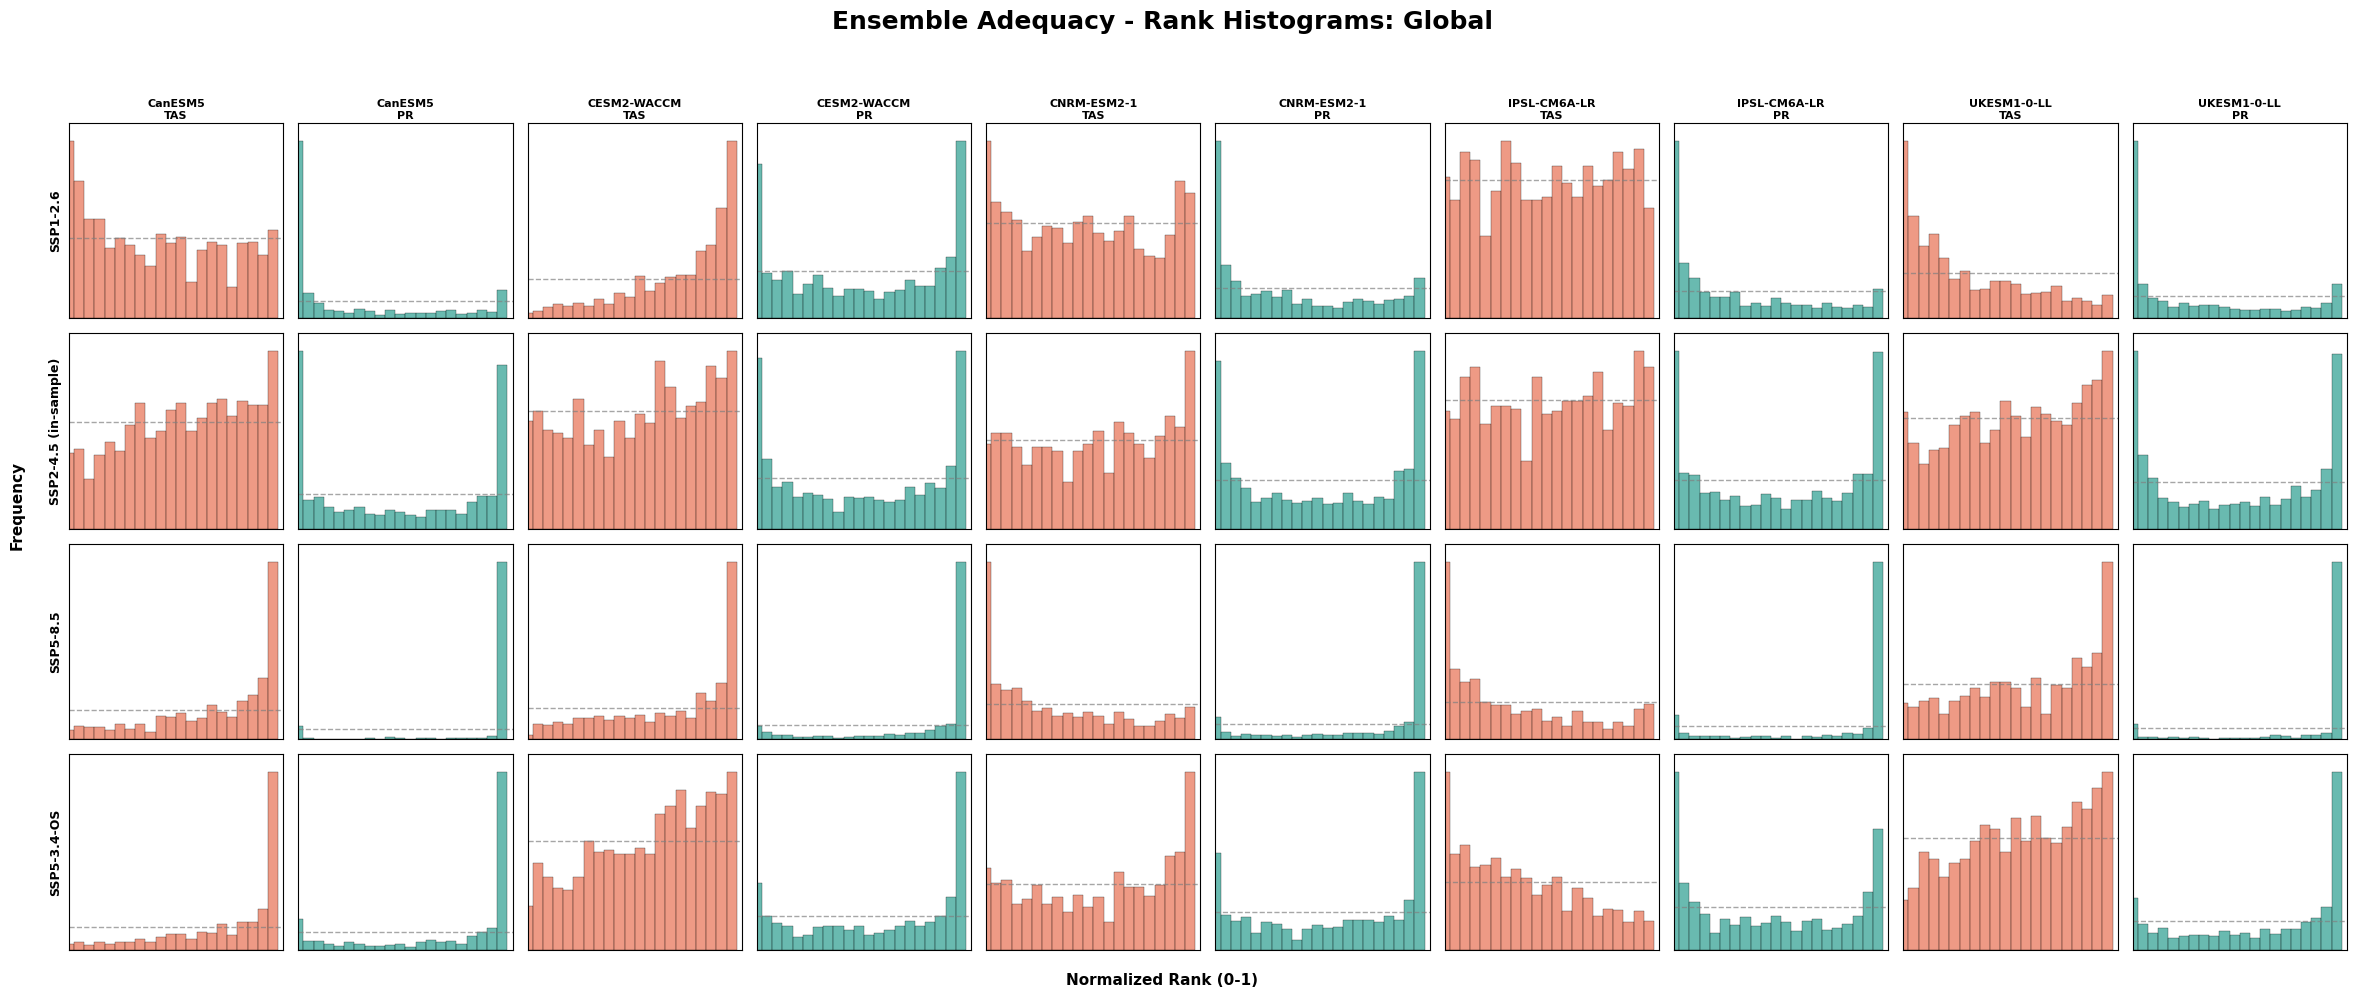

   ✅ Saved: suppfig_rank_histograms_global.pdf

Generating rank histograms for East Asia (Supplemental)...


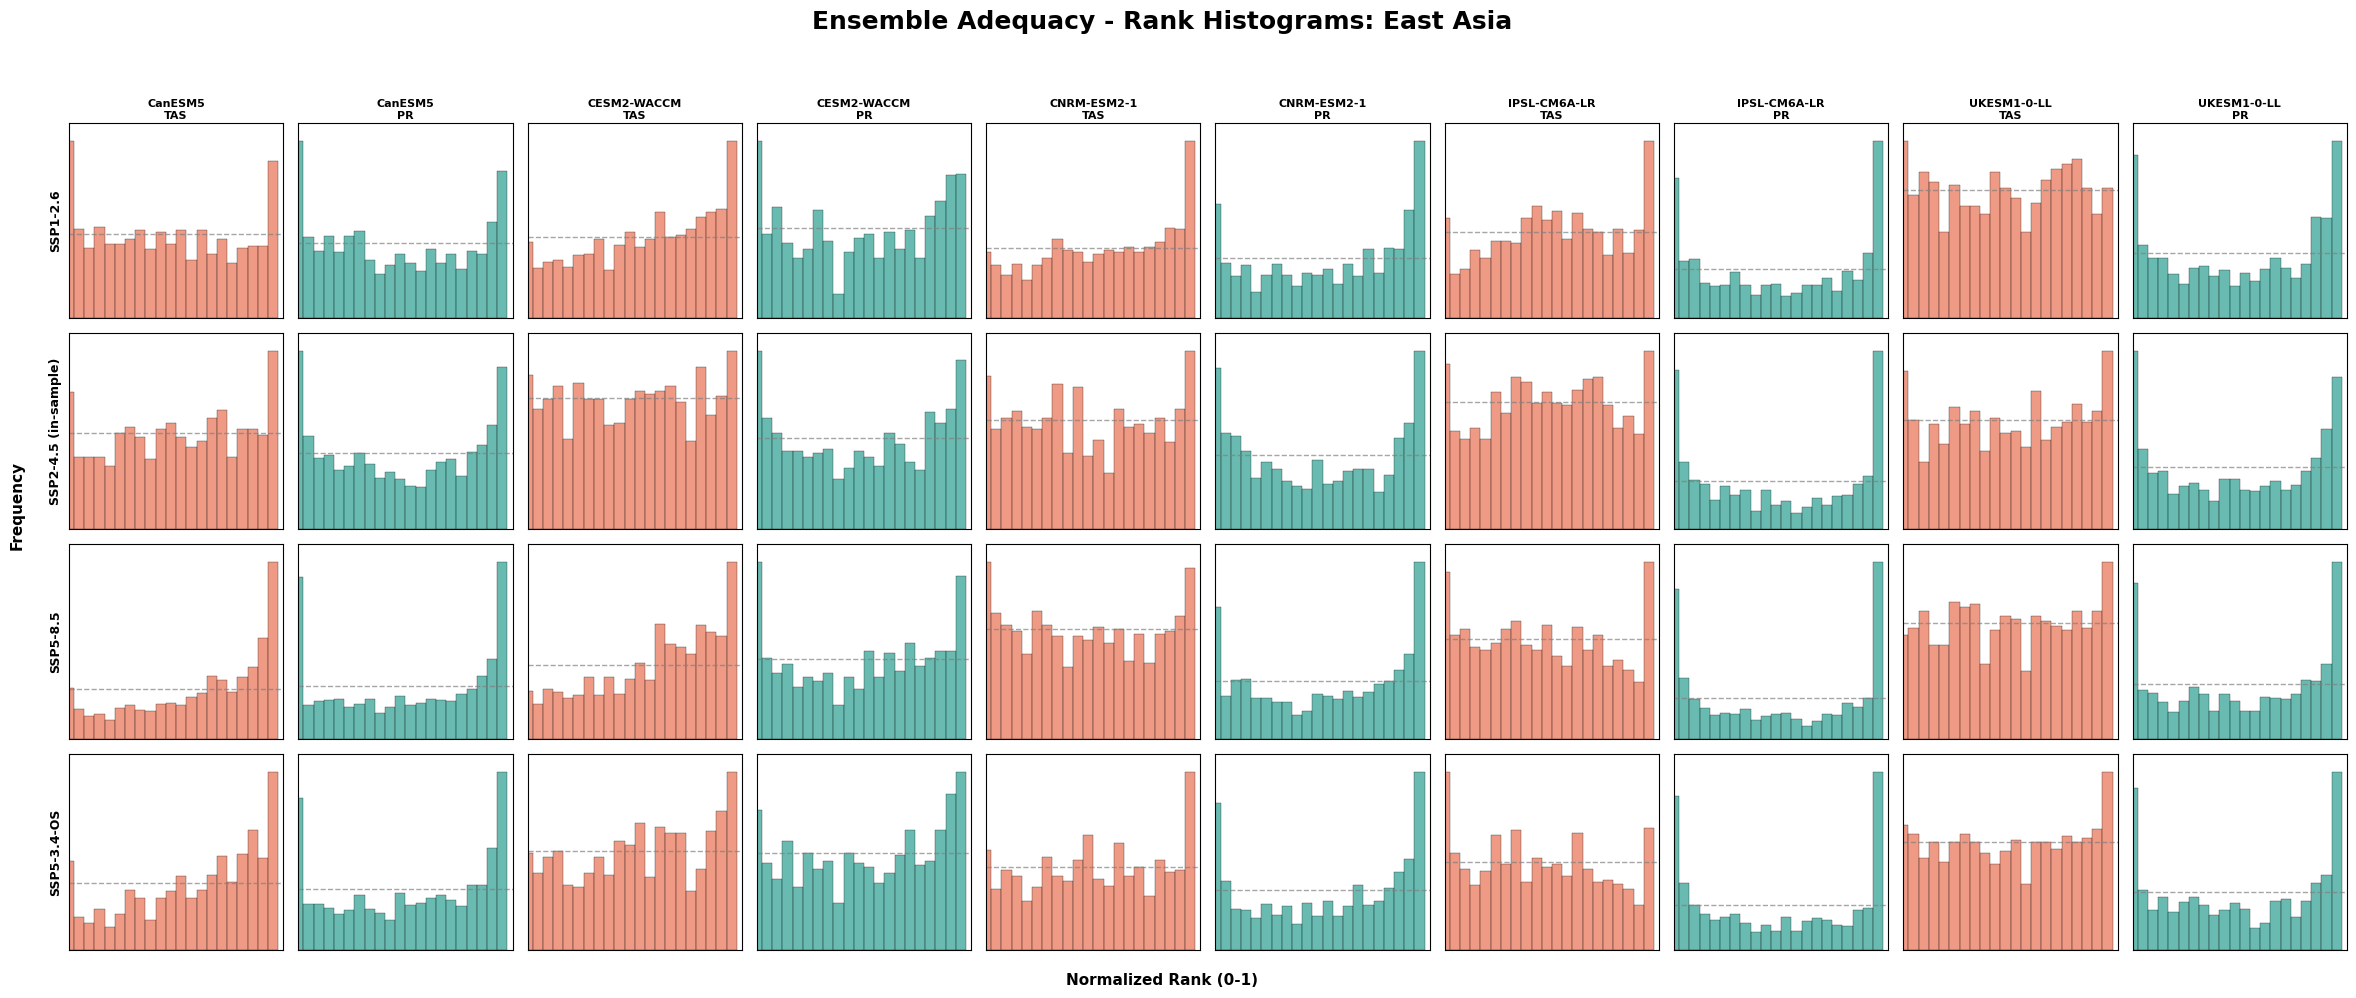

   ✅ Saved: suppfig_rank_histograms_regional_EAS.pdf

Generating rank histograms for Northern Europe (Supplemental)...


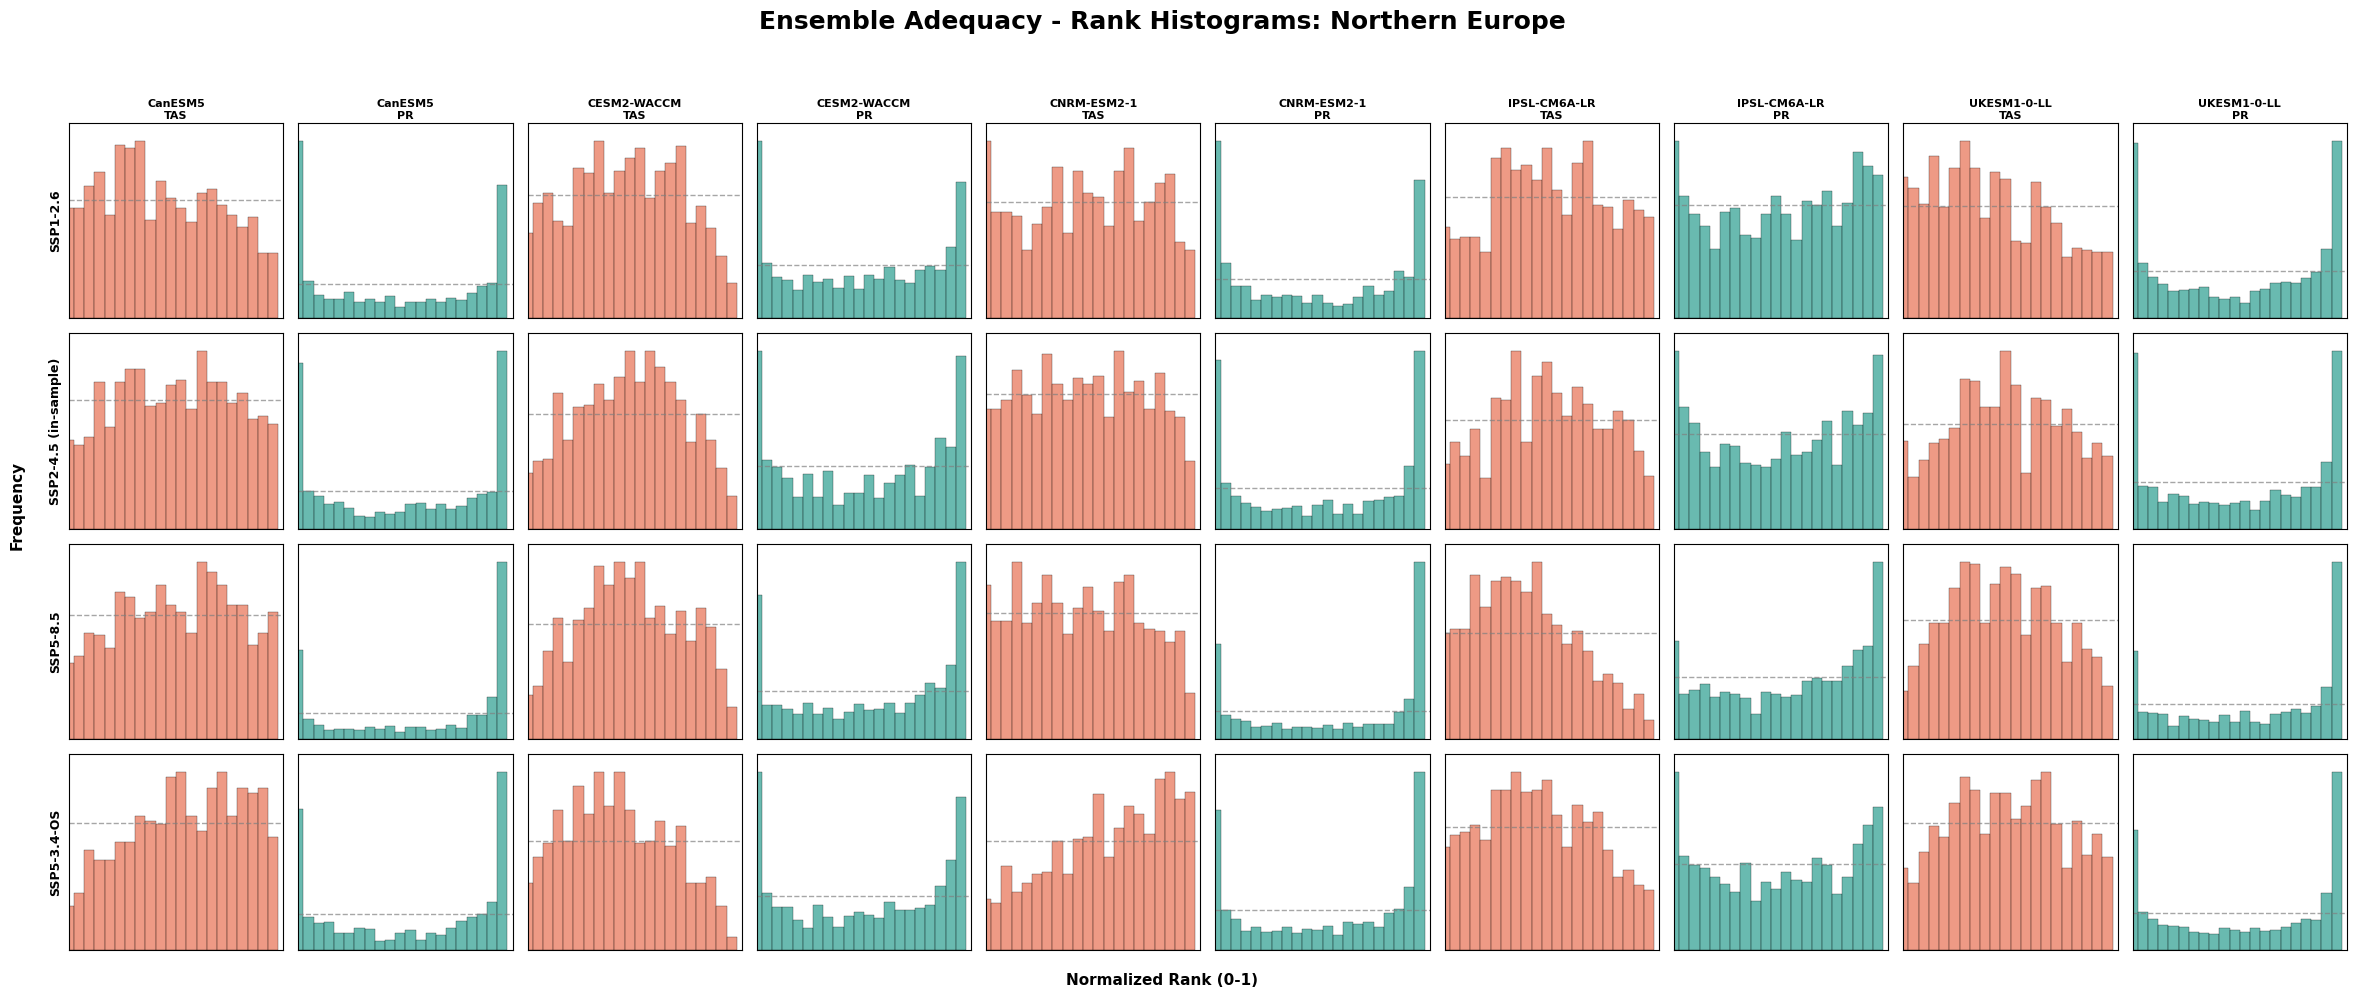

   ✅ Saved: suppfig_rank_histograms_regional_NEU.pdf

Generating rank histograms for Mumbai (Main paper - Figure 8)...


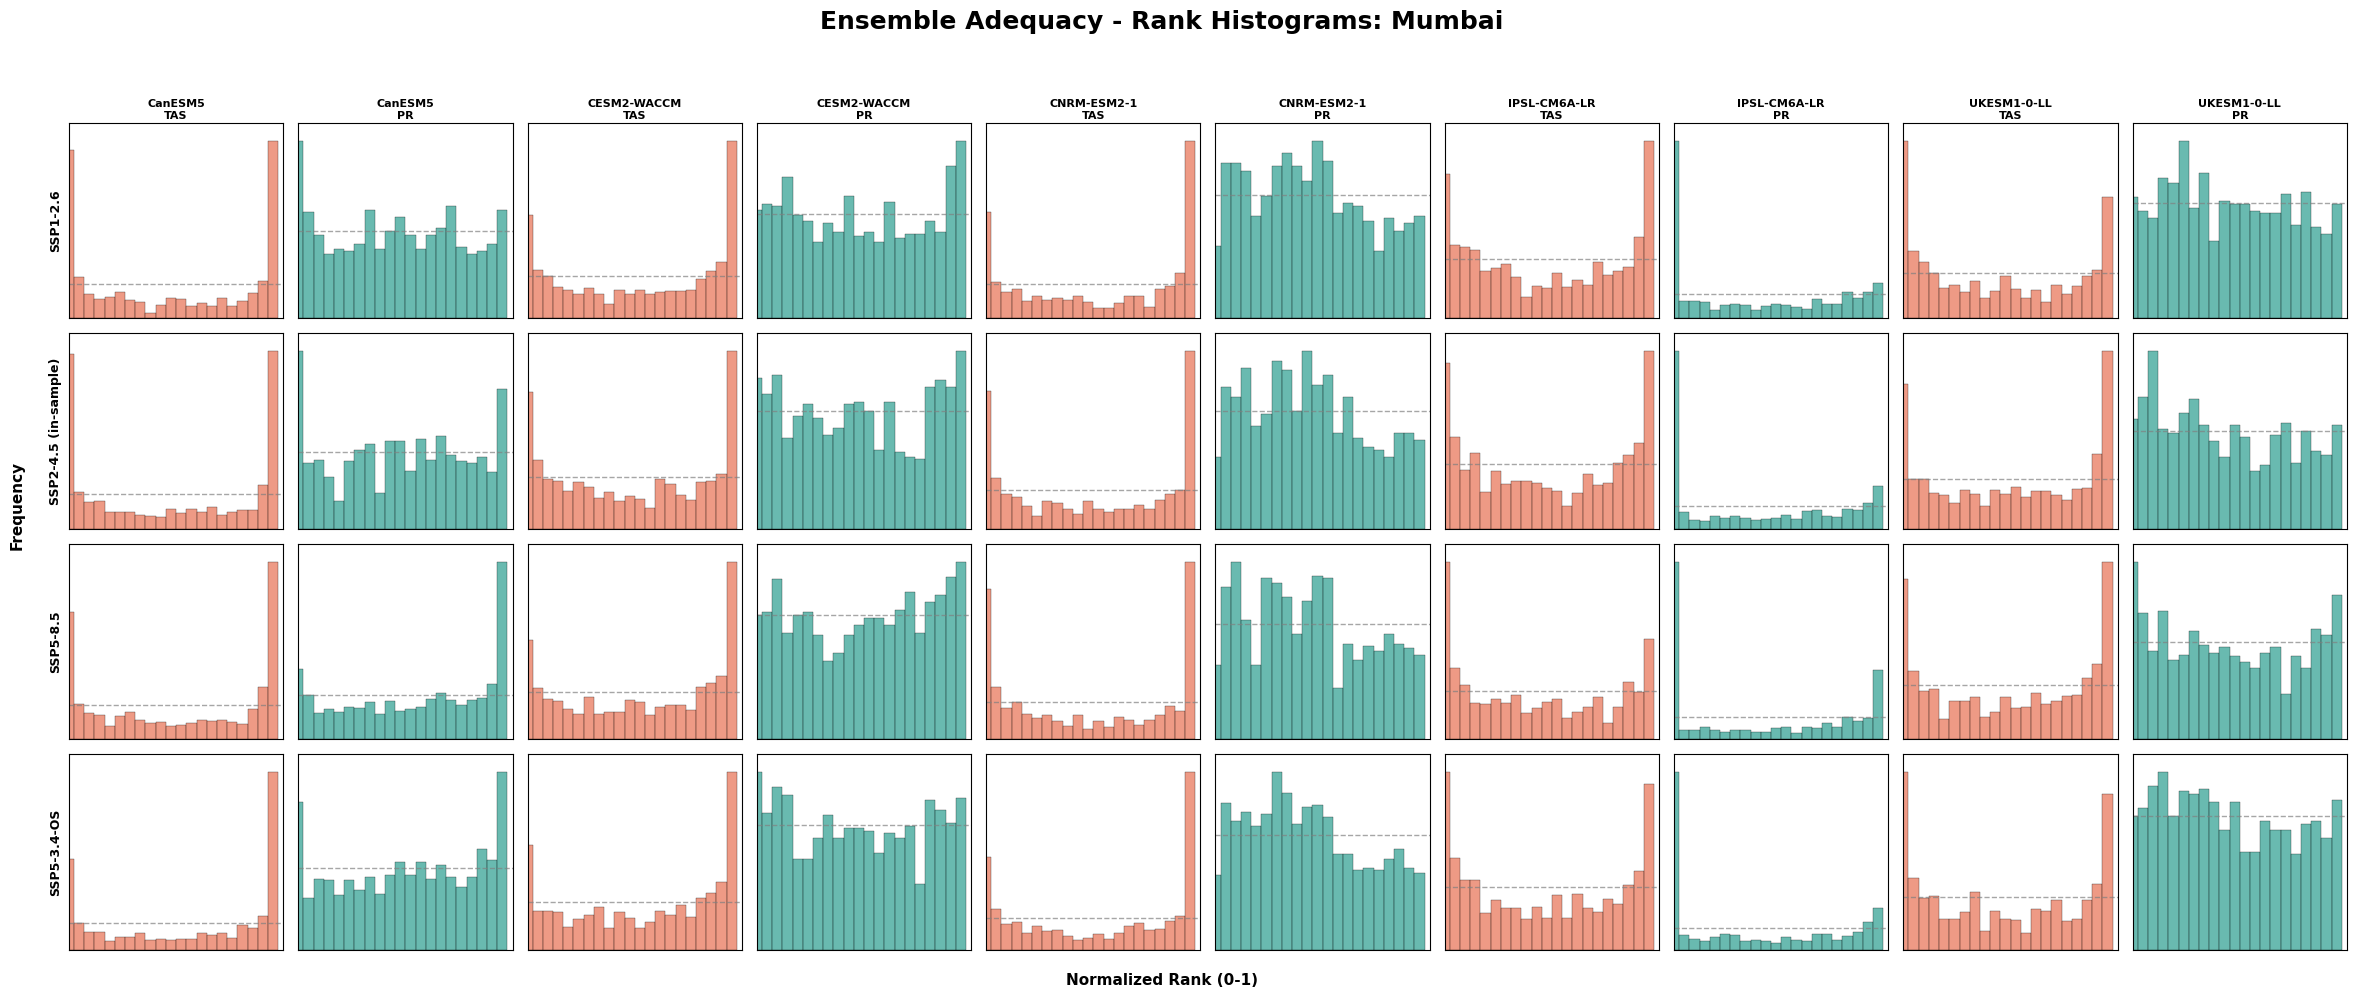

   ✅ Saved: fig8_rank_histograms_mumbai.pdf

Generating rank histograms for Oslo (Supplemental)...


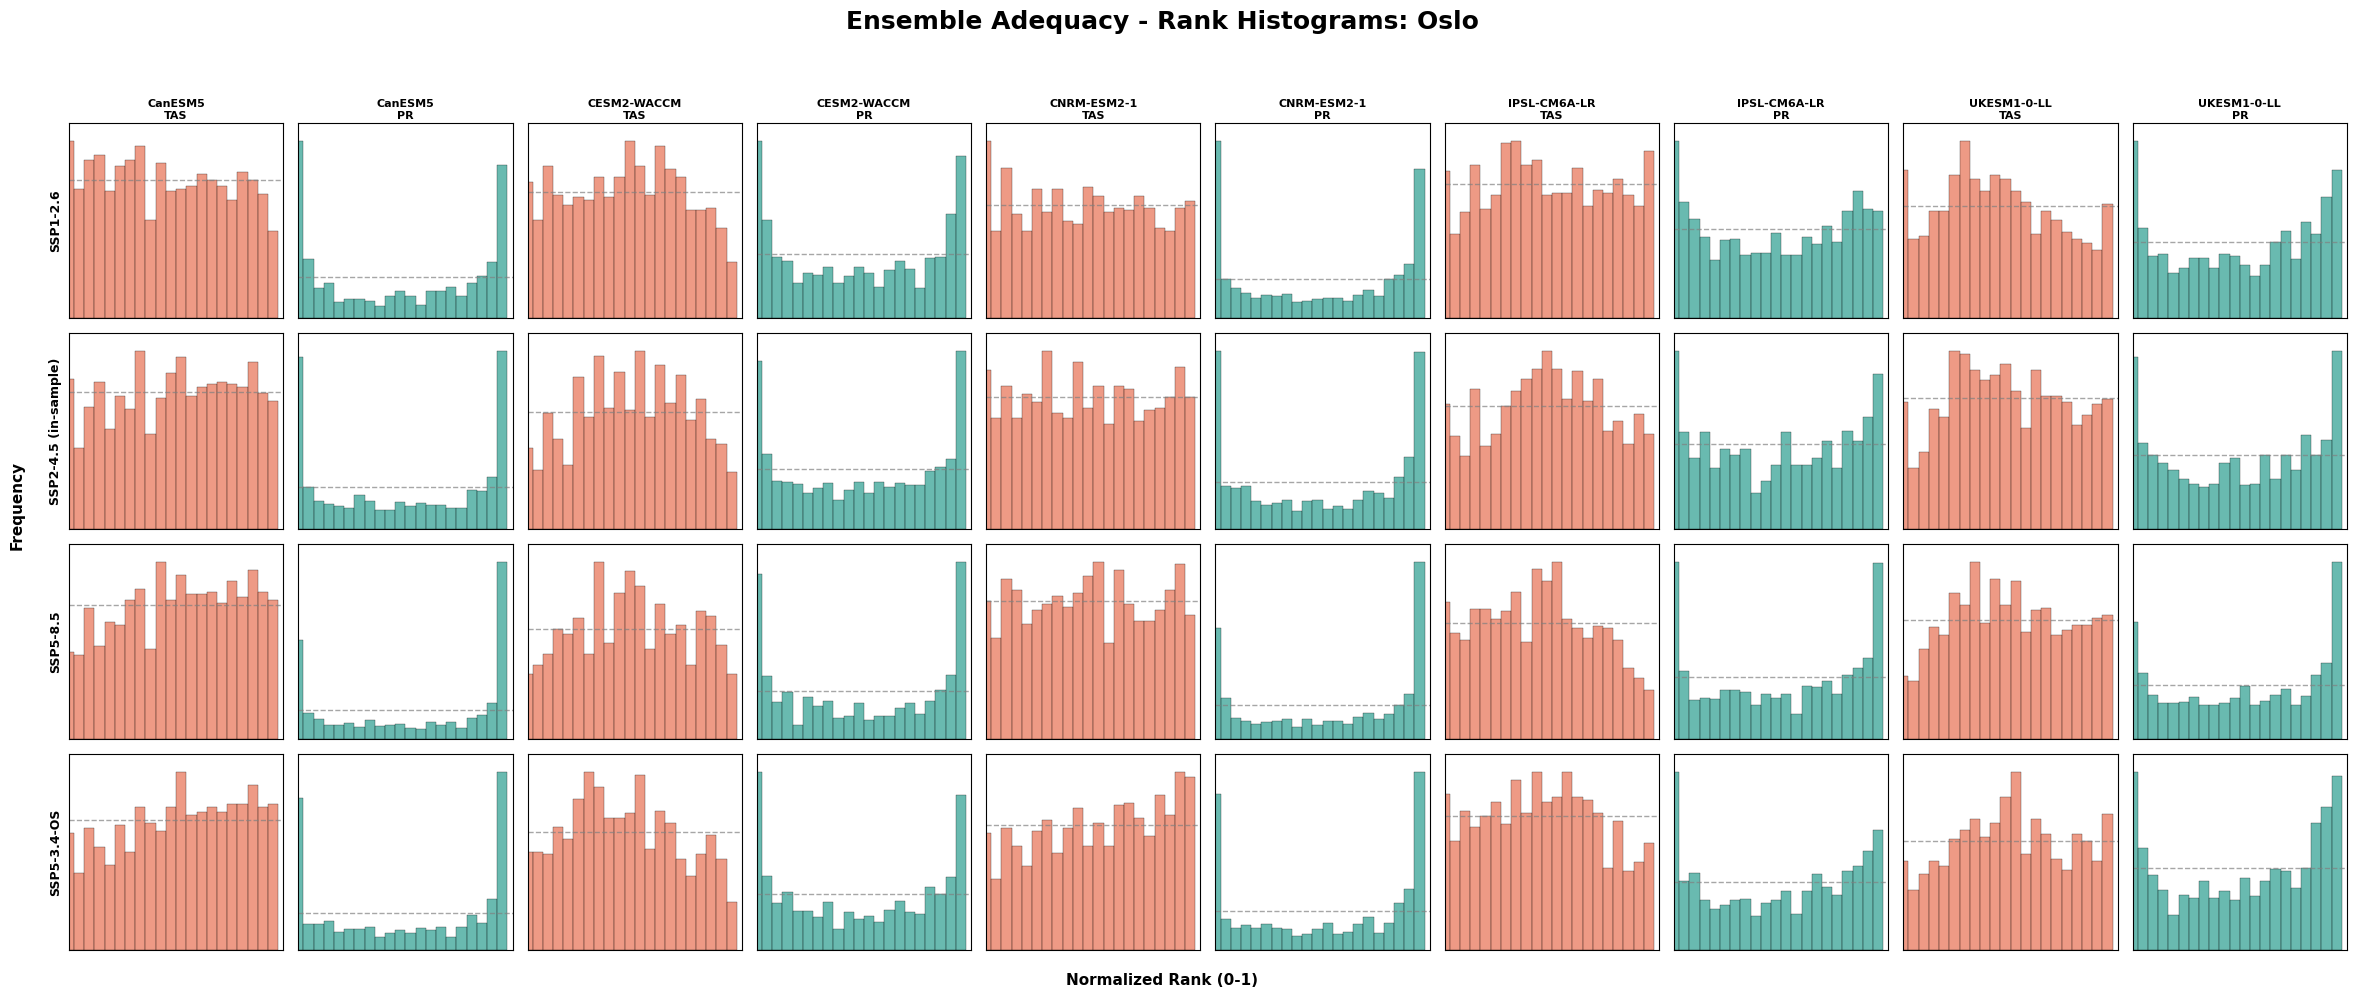

   ✅ Saved: suppfig_rank_histograms_oslo.pdf

✅ Rank histogram plots complete
   📊 Created 5 plots × 4 scenarios × 5 models × 2 variables
   📄 Main paper: Mumbai (Fig 8)
   📑 Supplemental: global, regional_EAS, regional_NEU, oslo

📌 Interpretation:
   • Uniform distribution: Ensemble adequately spans CMIP6 variability ✓
   • U-shaped: Under-dispersed (ensemble too narrow)
   • Dome-shaped: Over-dispersed (ensemble too wide)


In [59]:
if len(model_results) == 0:
    print("⚠️  No models to analyze. Run training cells first.")
else:
    # Color scheme for histograms
    tas_histogram = '#E76F51'      # Orange for temperature
    pr_histogram = '#2A9D8F'       # Teal for precipitation
    reference_line = 'gray'        # Dashed reference line

    model_list = list(models.keys())
    
    # Main paper spatial scale (rest go to supplemental)
    main_paper_scale = 'point:19.08,72.88'  # Mumbai

    # Create one plot per spatial scale
    for agg_key in spatial_aggregations:
        agg_label = aggregation_labels[agg_key]
        
        # Determine if this is main paper or supplemental
        is_main_paper = (agg_key == main_paper_scale)
        if is_main_paper:
            print(f"\nGenerating rank histograms for {agg_label} (Main paper - Figure 8)...")
        else:
            print(f"\nGenerating rank histograms for {agg_label} (Supplemental)...")

        # Create figure: 4 scenarios (rows) × 10 columns (2 vars × 5 models)
        fig, axes = plt.subplots(4, 10, figsize=(24, 10))
        
        # Main title and subtitle
        fig.suptitle(f'Ensemble Adequacy - Rank Histograms: {agg_label}',
                     fontsize=18, fontweight='bold', y=0.995)

        for row_idx, (scenario_code, scenario_name) in enumerate(validation_scenarios.items()):
            for model_idx, model_code in enumerate(model_list):
                if model_code not in model_results:
                    continue

                model_name = models[model_code]

                # Collect ranks for this scenario, model, and aggregation
                tas_ranks = []
                pr_ranks = []

                # Temperature ranks
                meteor_tas = model_results[model_code][scenario_code][agg_key]['tas']
                cmip6_tas = cmip6_data[model_code][scenario_code][agg_key]['tas']
                tas_ranks = calculate_ranks(meteor_tas, cmip6_tas)

                # Precipitation ranks
                meteor_pr = model_results[model_code][scenario_code][agg_key]['pr']
                cmip6_pr = cmip6_data[model_code][scenario_code][agg_key]['pr']
                pr_ranks = calculate_ranks(meteor_pr, cmip6_pr)

                # Column indices
                col_tas = model_idx * 2
                col_pr = model_idx * 2 + 1

                # === Temperature histogram ===
                ax_t = axes[row_idx, col_tas]

                n_bins = 21
                counts_t, bins_t = np.histogram(tas_ranks, bins=n_bins, range=(0, 1))

                ax_t.bar(bins_t[:-1], counts_t, width=1.0/n_bins, color=tas_histogram,
                        alpha=0.7, edgecolor='black', linewidth=0.3)

                uniform_height = len(tas_ranks) / n_bins
                ax_t.axhline(uniform_height, color=reference_line, linestyle='--',
                            linewidth=1, alpha=0.7)

                ax_t.set_xlim([0, 1])
                ax_t.set_ylim([0, max(counts_t) * 1.1] if max(counts_t) > 0 else 1)
                
                # Remove tick labels to save space
                ax_t.set_xticks([])
                ax_t.set_yticks([])

                # Column headers only on top row
                if row_idx == 0:
                    ax_t.set_title(f'{model_name}\nTAS', fontsize=8, fontweight='bold', pad=3)

                # Row labels only on leftmost column
                if col_tas == 0:
                    ax_t.set_ylabel(scenario_name, fontsize=9, fontweight='bold', rotation=90, labelpad=5)

                # === Precipitation histogram ===
                ax_p = axes[row_idx, col_pr]

                counts_p, bins_p = np.histogram(pr_ranks, bins=n_bins, range=(0, 1))

                ax_p.bar(bins_p[:-1], counts_p, width=1.0/n_bins, color=pr_histogram,
                        alpha=0.7, edgecolor='black', linewidth=0.3)

                uniform_height = len(pr_ranks) / n_bins
                ax_p.axhline(uniform_height, color=reference_line, linestyle='--',
                            linewidth=1, alpha=0.7)

                ax_p.set_xlim([0, 1])
                ax_p.set_ylim([0, max(counts_p) * 1.1] if max(counts_p) > 0 else 1)
                
                # Remove tick labels to save space
                ax_p.set_xticks([])
                ax_p.set_yticks([])

                # Column headers only on top row
                if row_idx == 0:
                    ax_p.set_title(f'{model_name}\nPR', fontsize=8, fontweight='bold', pad=3)

        # Add x-axis label at bottom center
        fig.text(0.5, 0.02, 'Normalized Rank (0-1)', ha='center', fontsize=11, fontweight='bold')
        
        # Add y-axis label on left side
        fig.text(0.02, 0.5, 'Frequency', va='center', rotation='vertical', fontsize=11, fontweight='bold')

        # Add interpretation text at bottom

        plt.tight_layout(rect=[0.03, 0.04, 1, 0.96])

        # Save figure with appropriate prefix
        if agg_key == 'global':
            base_filename = 'rank_histograms_global.pdf'
        elif agg_key.startswith('regional:'):
            region_code = agg_key.split(':')[1]
            base_filename = f'rank_histograms_regional_{region_code}.pdf'
        elif agg_key.startswith('point:'):
            # Use city name for point locations
            city_name = agg_label.split(',')[0].lower()  # e.g., "Mumbai" or "Oslo"
            base_filename = f'rank_histograms_{city_name}.pdf'
        
        # Add appropriate prefix (fig8 for Mumbai, suppfig for others)
        if is_main_paper:
            filename = f'fig8_{base_filename}'
        else:
            filename = f'suppfig_{base_filename}'
        
        plt.savefig(os.path.join(FIGURE_DIR, filename), bbox_inches='tight', dpi=300)
        plt.show()
        plt.close()

        print(f"   ✅ Saved: {filename}")

    print(f"\n✅ Rank histogram plots complete")
    print(f"   📊 Created {len(spatial_aggregations)} plots × 4 scenarios × {len(model_list)} models × 2 variables")
    print(f"   📄 Main paper: Mumbai (Fig 8)")
    print(f"   📑 Supplemental: global, regional_EAS, regional_NEU, oslo")
    print("\n📌 Interpretation:")
    print("   • Uniform distribution: Ensemble adequately spans CMIP6 variability ✓")
    print("   • U-shaped: Under-dispersed (ensemble too narrow)")
    print("   • Dome-shaped: Over-dispersed (ensemble too wide)")

## 5. Quantitative Validation Metrics

Calculate error metrics for each model and scenario.

In [53]:
if len(model_results) == 0:
    print("⚠️  No models to analyze. Run training cells first.")
else:
    print("="*90)
    print("VALIDATION METRICS: METEOR vs CMIP6")
    print("="*90)

    for model_code, model_name in models.items():
        if model_code not in model_results:
            continue
        
        print(f"\n{model_name}:")
        print("-" * 90)
        
        for scenario_code, scenario_name in validation_scenarios.items():
            # Get data
            meteor_tas = model_results[model_code][scenario_code]['global']['tas'].mean(axis=0)
            meteor_pr = model_results[model_code][scenario_code]['global']['pr'].mean(axis=0)
            
            cmip6_tas = cmip6_data[model_code][scenario_code]['global']['tas']
            cmip6_pr = cmip6_data[model_code][scenario_code]['global']['pr']
            
            if cmip6_tas.ndim == 2:
                cmip6_tas = cmip6_tas.mean(dim='ens').values
                cmip6_pr = cmip6_pr.mean(dim='ens').values
            else:
                cmip6_tas = cmip6_tas.values
                cmip6_pr = cmip6_pr.values
            
            # Align time dimensions
            n_min = min(len(meteor_tas), len(cmip6_tas))
            meteor_tas_sub = meteor_tas[:n_min]
            meteor_pr_sub = meteor_pr[:n_min]
            cmip6_tas_sub = cmip6_tas[:n_min]
            cmip6_pr_sub = cmip6_pr[:n_min]
            
            # Calculate metrics
            tas_rmse = np.sqrt(np.mean((meteor_tas_sub - cmip6_tas_sub)**2))
            tas_bias = np.mean(meteor_tas_sub - cmip6_tas_sub)
            tas_corr = np.corrcoef(meteor_tas_sub, cmip6_tas_sub)[0, 1]
            
            pr_rmse = np.sqrt(np.mean((meteor_pr_sub - cmip6_pr_sub)**2))
            pr_bias = np.mean(meteor_pr_sub - cmip6_pr_sub)
            pr_corr = np.corrcoef(meteor_pr_sub, cmip6_pr_sub)[0, 1]
            
            print(f"  {scenario_name:25s} | TAS RMSE: {tas_rmse:.4f} K | Bias: {tas_bias:+.4f} K | Corr: {tas_corr:.4f}")
            print(f"  {' ':25s} | PR  RMSE: {pr_rmse:.6f}   | Bias: {pr_bias:+.6f}   | Corr: {pr_corr:.4f}")

    print("\n" + "="*90)
    print("✅ Validation metrics complete")
    print("="*90)

VALIDATION METRICS: METEOR vs CMIP6

CanESM5:
------------------------------------------------------------------------------------------
  SSP1-2.6                  | TAS RMSE: 0.1681 K | Bias: +0.0333 K | Corr: 0.9922
                            | PR  RMSE: 0.000000   | Bias: +0.000000   | Corr: 0.9341
  SSP2-4.5 (in-sample)      | TAS RMSE: 0.1493 K | Bias: -0.0331 K | Corr: 0.9951
                            | PR  RMSE: 0.000000   | Bias: +0.000000   | Corr: 0.9499
  SSP5-8.5                  | TAS RMSE: 0.2523 K | Bias: -0.1476 K | Corr: 0.9968
                            | PR  RMSE: 0.000001   | Bias: -0.000001   | Corr: 0.9722
  SSP5-3.4-OS               | TAS RMSE: 0.2625 K | Bias: -0.1738 K | Corr: 0.9908
                            | PR  RMSE: 0.000000   | Bias: -0.000000   | Corr: 0.9485

CESM2-WACCM:
------------------------------------------------------------------------------------------
  SSP1-2.6                  | TAS RMSE: 0.2092 K | Bias: -0.1392 K | Corr: 0.9927
    